# Tox21 Drug Toxicity Prediction — New Research Notebook

এই notebook-এ previous modified workflow intact রাখা হয়েছে, কিন্তু নতুন researcher recommendation যোগ করা হয়েছে:

- Evaluation metrics: **AUC-ROC, Accuracy, Balanced Accuracy, F1-score**
- Runtime reduce করার জন্য **SVM RBF বাদ দিয়ে Linear SVM** use করা হয়েছে
- **Naive Bayes বাদ** রাখা হয়েছে
- **3-fold cross-validation** রাখা হয়েছে
- Visual representation screenshot-style রাখা হয়েছে
- **CapsNet + Linear SVM** hybrid রাখা হয়েছে
- New addition: **DenseNet121 2D molecule image feature extractor + Linear SVM**
- New addition: **DenseNet121 + chemical features + Linear SVM** best setup
- New addition: **Soft-voting ensemble** using chemical fingerprint models + DenseNet image model

Target: **Tox21 multi-label binary toxicity prediction** with missing labels and severe class imbalance.


## 0. Environment setup

RDKit molecular fingerprint/descriptor বানানোর জন্য দরকার। কোনো package missing হলে নিচের install line uncomment করে run করবে।

In [ ]:
# Colab/Kaggle/local environment এ দরকার হলে uncomment করে run করো:
# !pip -q install rdkit-pypi xgboost lightgbm imbalanced-learn tensorflow joblib

In [1]:
print("Hello")

Hello


## 1. Import libraries

এই অংশে data handling, plotting, ML, metric, CV এবং model saving tools import করা হলো।

In [2]:
import os
import math
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)

print("Basic libraries imported")

Basic libraries imported


In [3]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from scipy.special import expit
import joblib

print("Scikit-learn tools imported")

Scikit-learn tools imported


In [4]:
try:
    from rdkit import Chem
    from rdkit.Chem import AllChem, MACCSkeys, Descriptors, rdMolDescriptors
    from rdkit.Chem.MolStandardize import rdMolStandardize
    from rdkit import RDLogger
    RDLogger.DisableLog("rdApp.*")
    RDKIT_AVAILABLE = True
    print("RDKit available")
except Exception as e:
    RDKIT_AVAILABLE = False
    print("RDKit import failed:", e)

RDKit available


In [5]:
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
    print("XGBoost available")
except Exception as e:
    XGB_AVAILABLE = False
    print("XGBoost unavailable:", e)

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
    print("LightGBM available")
except Exception as e:
    LGBM_AVAILABLE = False
    print("LightGBM unavailable:", e)

try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
    print("imbalanced-learn available")
except Exception as e:
    IMBLEARN_AVAILABLE = False
    print("imbalanced-learn unavailable:", e)

XGBoost available
LightGBM available
imbalanced-learn available


In [6]:
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TF_AVAILABLE = True
    print("TensorFlow available:", tf.__version__)
except Exception as e:
    TF_AVAILABLE = False
    print("TensorFlow unavailable. Deep learning blocks will be skipped:", e)

TensorFlow available: 2.21.0


## 2. Global configuration

Reproducibility, split ratio, CV folds এবং result folder define করা হলো।

In [7]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

N_BITS = 2048
RADIUS = 2
TRAIN_SIZE = 0.70
VAL_SIZE = 0.10
TEST_SIZE = 0.20
N_SPLITS_CV = 3

N_ESTIMATORS = 300
LINEAR_SVM_C = 1.0

DL_EPOCHS = 35
DL_BATCH_SIZE = 128
DL_PATIENCE = 7
DL_LEARNING_RATE = 1e-3

# Runtime control flags
RUN_3FOLD_CV = True
RUN_DEEP_MODELS = True
RUN_CAPSNET_SVM = True

# DenseNet121 image feature extraction একটু heavy; GPU/Colab হলে True রাখো।
RUN_DENSENET121 = True
RUN_DENSENET_ENSEMBLE = True
IMAGE_SIZE = 224
DENSENET_BATCH_SIZE = 32

RESULT_DIR = Path("tox21_new_outputs")
RESULT_DIR.mkdir(exist_ok=True)

print("Configuration ready")


Configuration ready


## 3. Load Tox21 dataset

Notebook একই folder, `/mnt/data`, অথবা Colab `/content` path থেকে `tox21.csv` খুঁজবে।

In [8]:
possible_paths = [
    Path("tox21.csv"),
    Path("/mnt/data/tox21.csv"),
    Path("/content/tox21.csv"),
    Path("../input/tox21/tox21.csv"),
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("tox21.csv পাওয়া যায়নি। Notebook-এর পাশে tox21.csv রাখো।")

df_raw = pd.read_csv(DATA_PATH)
print("Using dataset:", DATA_PATH)
print("Raw shape:", df_raw.shape)
df_raw.head()

Using dataset: tox21.csv
Raw shape: (7831, 14)


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [9]:
TARGET_COLS = [c for c in df_raw.columns if c not in ["mol_id", "smiles"]]
print("Number of Tox21 endpoints:", len(TARGET_COLS))
print(TARGET_COLS)

for col in TARGET_COLS:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

Number of Tox21 endpoints: 12
['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']


## 4. Dataset challenge table: missing values and imbalance

Tox21-এ অনেক endpoint-এ label missing এবং toxic positive class খুব কম। তাই accuracy একা যথেষ্ট নয়।

In [10]:
def make_endpoint_summary(df, target_cols):
    rows = []
    total_n = len(df)
    for col in target_cols:
        y = df[col]
        y_labeled = y.dropna().astype(int)
        n_pos = int((y_labeled == 1).sum())
        n_neg = int((y_labeled == 0).sum())
        n_missing = int(y.isna().sum())
        labeled = int(len(y_labeled))
        pos_rate = 100 * n_pos / max(labeled, 1)
        miss_rate = 100 * n_missing / max(total_n, 1)
        ratio = n_neg / max(n_pos, 1)
        rows.append({
            "Endpoint": col,
            "Labeled": labeled,
            "Toxic (1)": n_pos,
            "Non-Toxic (0)": n_neg,
            "Missing": n_missing,
            "Missing %": miss_rate,
            "Pos Rate %": pos_rate,
            "Imbalance": f"{ratio:.1f} : 1",
            "RatioValue": ratio,
        })
    return pd.DataFrame(rows)

endpoint_summary = make_endpoint_summary(df_raw, TARGET_COLS)
endpoint_summary_display = endpoint_summary.drop(columns=["RatioValue"]).copy()
endpoint_summary_display["Missing %"] = endpoint_summary_display["Missing %"].round(1)
endpoint_summary_display["Pos Rate %"] = endpoint_summary_display["Pos Rate %"].round(1)
endpoint_summary_display

,Endpoint,Labeled,Toxic (1),Non-Toxic (0),Missing,Missing %,Pos Rate %,Imbalance
0,NR-AR,7265,309,6956,566,7.2,4.3,22.5 : 1
1,NR-AR-LBD,6758,237,6521,1073,13.7,3.5,27.5 : 1
2,NR-AhR,6549,768,5781,1282,16.4,11.7,7.5 : 1
3,NR-Aromatase,5821,300,5521,2010,25.7,5.2,18.4 : 1
4,NR-ER,6193,793,5400,1638,20.9,12.8,6.8 : 1
5,NR-ER-LBD,6955,350,6605,876,11.2,5.0,18.9 : 1
6,NR-PPAR-gamma,6450,186,6264,1381,17.6,2.9,33.7 : 1
7,SR-ARE,5832,942,4890,1999,25.5,16.2,5.2 : 1
8,SR-ATAD5,7072,264,6808,759,9.7,3.7,25.8 : 1
9,SR-HSE,6467,372,6095,1364,17.4,5.8,16.4 : 1


## 5. Visual EDA: missing labels and class imbalance

Red = severe issue, Orange = moderate, Green = acceptable. Screenshot-style horizontal bar chart তৈরি করা হলো।

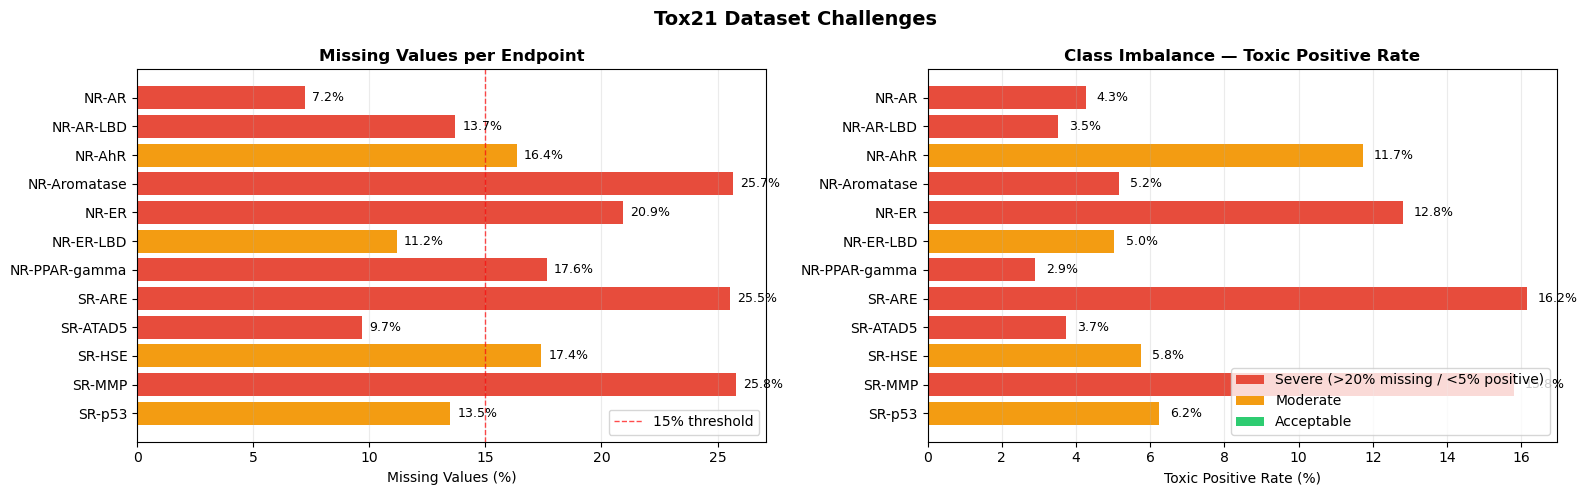

In [11]:
def severity_color(missing_pct, pos_rate):
    if missing_pct > 20 or pos_rate < 5:
        return "#e74c3c"   # severe red
    if missing_pct > 15 or pos_rate < 8:
        return "#f39c12"   # moderate orange
    return "#2ecc71"       # acceptable green

summary_plot = endpoint_summary.copy()
summary_plot = summary_plot.iloc[::-1].reset_index(drop=True)
colors = [severity_color(m, p) for m, p in zip(summary_plot["Missing %"], summary_plot["Pos Rate %"])]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(summary_plot["Endpoint"], summary_plot["Missing %"], color=colors)
axes[0].axvline(15, color="red", linestyle="--", linewidth=1, alpha=0.7, label="15% threshold")
axes[0].set_title("Missing Values per Endpoint", fontweight="bold")
axes[0].set_xlabel("Missing Values (%)")
axes[0].grid(axis="x", alpha=0.25)
axes[0].legend(loc="lower right")
for i, v in enumerate(summary_plot["Missing %"]):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)

axes[1].barh(summary_plot["Endpoint"], summary_plot["Pos Rate %"], color=colors)
axes[1].set_title("Class Imbalance — Toxic Positive Rate", fontweight="bold")
axes[1].set_xlabel("Toxic Positive Rate (%)")
axes[1].grid(axis="x", alpha=0.25)
for i, v in enumerate(summary_plot["Pos Rate %"]):
    axes[1].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#e74c3c", label="Severe (>20% missing / <5% positive)"),
    Patch(facecolor="#f39c12", label="Moderate"),
    Patch(facecolor="#2ecc71", label="Acceptable"),
]
axes[1].legend(handles=legend_elements, loc="lower right")

fig.suptitle("Tox21 Dataset Challenges", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

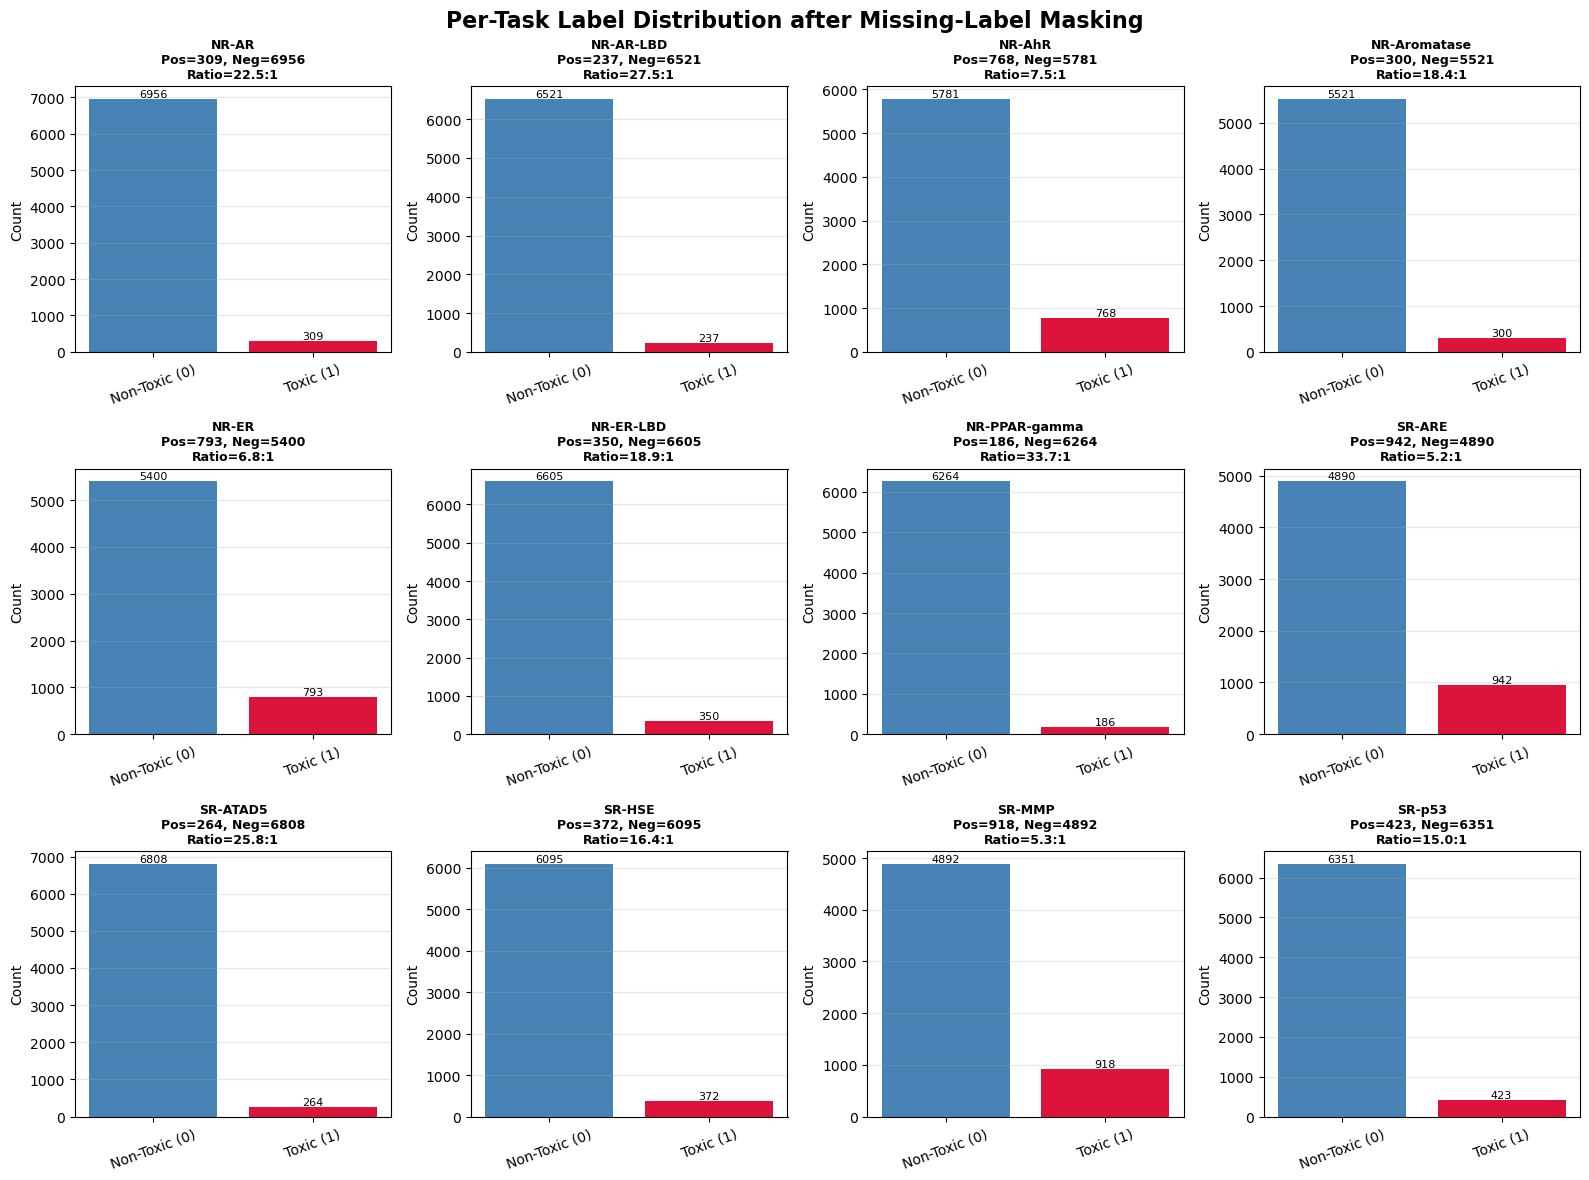

In [12]:
# ==========================================================
# Per-Task Label Distribution after Missing-Label Masking
# ==========================================================

import math
import matplotlib.pyplot as plt

n_cols = 4
n_rows = math.ceil(len(TARGET_COLS) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.ravel()

for i, task in enumerate(TARGET_COLS):

    # Remove missing labels
    y_valid = df_raw[task].dropna().astype(int)

    # Count positive & negative samples
    n_neg = int((y_valid == 0).sum())
    n_pos = int((y_valid == 1).sum())

    # Plot
    axes[i].bar(
        ["Non-Toxic (0)", "Toxic (1)"],
        [n_neg, n_pos],
        color=["steelblue", "crimson"]
    )

    # Title
    axes[i].set_title(
        f"{task}\nPos={n_pos}, Neg={n_neg}\nRatio={n_neg/max(n_pos,1):.1f}:1",
        fontsize=9,
        fontweight="bold"
    )

    axes[i].set_ylabel("Count")
    axes[i].grid(axis="y", alpha=0.30)

    # Value labels
    axes[i].text(
        0, n_neg,
        str(n_neg),
        ha="center",
        va="bottom",
        fontsize=8
    )

    axes[i].text(
        1, n_pos,
        str(n_pos),
        ha="center",
        va="bottom",
        fontsize=8
    )

    axes[i].tick_params(axis="x", labelrotation=20)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Per-Task Label Distribution after Missing-Label Masking",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 6. Chemical preprocessing

Research-quality preprocessing: invalid SMILES remove, largest fragment choose, normalize, uncharge, canonical SMILES generate।

In [13]:
if not RDKIT_AVAILABLE:
    raise ImportError("RDKit দরকার। Install: pip install rdkit-pypi")

normalizer = rdMolStandardize.Normalizer()
uncharger = rdMolStandardize.Uncharger()
fragment_chooser = rdMolStandardize.LargestFragmentChooser()

def clean_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return None, None
        mol = fragment_chooser.choose(mol)
        mol = normalizer.normalize(mol)
        mol = uncharger.uncharge(mol)
        Chem.SanitizeMol(mol)
        can = Chem.MolToSmiles(mol, canonical=True)
        return can, mol
    except Exception:
        return None, None

cleaned = df_raw["smiles"].apply(clean_smiles)
df = df_raw.copy()
df["canonical_smiles"] = [x[0] for x in cleaned]
df["mol"] = [x[1] for x in cleaned]

invalid_mask = df["mol"].isna()
print("Invalid SMILES:", int(invalid_mask.sum()))

df = df.loc[~invalid_mask].reset_index(drop=True)
print("After invalid removal:", df.shape)

Invalid SMILES: 9
After invalid removal: (7822, 16)


In [14]:
# Duplicate canonical SMILES check
n_dups = int(df["canonical_smiles"].duplicated().sum())
print("Duplicate canonical SMILES:", n_dups)

if n_dups > 0:
    # Duplicate থাকলে label-wise first non-null aggregation করা হবে।
    agg_dict = {"smiles": "first", "mol_id": "first", "mol": "first"}
    for col in TARGET_COLS:
        agg_dict[col] = lambda s: s.dropna().iloc[0] if len(s.dropna()) else np.nan
    df = df.groupby("canonical_smiles", as_index=False).agg(agg_dict)
    print("After duplicate aggregation:", df.shape)

Duplicate canonical SMILES: 211
After duplicate aggregation: (7611, 16)


## 7. Feature engineering

Morgan ECFP4, MACCS keys, এবং selected RDKit physicochemical descriptors combine করা হয়েছে।

In [15]:
def morgan_fp(mol, n_bits=N_BITS, radius=RADIUS):
    arr = np.zeros((n_bits,), dtype=np.int8)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    from rdkit import DataStructs
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def maccs_fp(mol):
    arr = np.zeros((167,), dtype=np.int8)
    fp = MACCSkeys.GenMACCSKeys(mol)
    from rdkit import DataStructs
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

DESC_FUNCS = {
    "MolWt": Descriptors.MolWt,
    "MolLogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA,
    "NumHDonors": Descriptors.NumHDonors,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "RingCount": Descriptors.RingCount,
    "HeavyAtomCount": Descriptors.HeavyAtomCount,
    "FractionCSP3": Descriptors.FractionCSP3,
    "NumAromaticRings": rdMolDescriptors.CalcNumAromaticRings,
    "NumAliphaticRings": rdMolDescriptors.CalcNumAliphaticRings,
}

def rdkit_desc(mol):
    values = []
    for name, func in DESC_FUNCS.items():
        try:
            values.append(float(func(mol)))
        except Exception:
            values.append(np.nan)
    return values

In [16]:
print("Generating Morgan fingerprints...")
X_morgan = np.vstack(df["mol"].apply(morgan_fp).values).astype(np.float32)
print("Morgan shape:", X_morgan.shape)

print("Generating MACCS keys...")
X_maccs = np.vstack(df["mol"].apply(maccs_fp).values).astype(np.float32)
print("MACCS shape:", X_maccs.shape)

print("Generating RDKit descriptors...")
X_desc_raw = np.vstack(df["mol"].apply(rdkit_desc).values).astype(np.float32)
desc_names = list(DESC_FUNCS.keys())
print("Descriptor shape:", X_desc_raw.shape)

Generating Morgan fingerprints...
Morgan shape: (7611, 2048)
Generating MACCS keys...
MACCS shape: (7611, 167)
Generating RDKit descriptors...
Descriptor shape: (7611, 11)


In [17]:
# Descriptor imputation + scaling
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
X_desc = scaler.fit_transform(imputer.fit_transform(X_desc_raw)).astype(np.float32)

# Final feature matrix: Morgan + MACCS + scaled descriptors
X = np.hstack([X_morgan, X_maccs, X_desc]).astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

print("Final X shape:", X.shape)
print("Y shape:", Y.shape)
print("Missing labels in Y:", int(np.isnan(Y).sum()))

Final X shape: (7611, 2226)
Y shape: (7611, 12)
Missing labels in Y: 15550


## 8. Train / Validation / Test split = 70 / 10 / 20

Missing labels split করার সময় target হিসেবে use করা হয়নি। Stratification-এর জন্য `any_toxic` indicator use করা হয়েছে।

In [18]:
# Row-level stratification: at least one observed toxic endpoint আছে কিনা
any_toxic = np.nanmax(np.where(np.isnan(Y), 0, Y), axis=1).astype(int)

idx_all = np.arange(len(df))
idx_train, idx_temp = train_test_split(
    idx_all,
    test_size=(VAL_SIZE + TEST_SIZE),
    random_state=SEED,
    stratify=any_toxic,
)

relative_test_size = TEST_SIZE / (VAL_SIZE + TEST_SIZE)
idx_val, idx_test = train_test_split(
    idx_temp,
    test_size=relative_test_size,
    random_state=SEED,
    stratify=any_toxic[idx_temp],
)

X_train, Y_train = X[idx_train], Y[idx_train]
X_val, Y_val = X[idx_val], Y[idx_val]
X_test, Y_test = X[idx_test], Y[idx_test]

print("Train:", X_train.shape, Y_train.shape)
print("Validation:", X_val.shape, Y_val.shape)
print("Test:", X_test.shape, Y_test.shape)
print("Split ratio:", len(idx_train), len(idx_val), len(idx_test))

Train: (5327, 2226) (5327, 12)
Validation: (761, 2226) (761, 12)
Test: (1523, 2226) (1523, 12)
Split ratio: 5327 761 1523


In [19]:
split_df = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(idx_train), len(idx_val), len(idx_test)],
    "percentage": [100*len(idx_train)/len(df), 100*len(idx_val)/len(df), 100*len(idx_test)/len(df)]
})
split_df

,split,rows,percentage
0,train,5327,69.990803
1,validation,761,9.998686
2,test,1523,20.010511


## 9. Metric functions and threshold tuning

এই notebook-এ requested metrics only রাখা হয়েছে: **AUC-ROC, Accuracy, Balanced Accuracy, F1-score**।

In [20]:
def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan
    try:
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan

def threshold_search(y_true, y_score, metric="f1"):
    # Validation set ব্যবহার করে endpoint-wise threshold tune করা হয়।
    thresholds = np.linspace(0.05, 0.95, 91)
    best_t, best_s = 0.5, -1
    y_true = np.asarray(y_true).astype(int)
    for t in thresholds:
        pred = (y_score >= t).astype(int)
        if metric == "balanced_accuracy":
            s = balanced_accuracy_score(y_true, pred)
        else:
            s = f1_score(y_true, pred, zero_division=0)
        if s > best_s:
            best_s = s
            best_t = float(t)
    return best_t, best_s

def classification_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)
    return {
        "AUC-ROC": safe_auc(y_true, y_score),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

def model_scores(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        return expit(model.decision_function(X_data))
    return model.predict(X_data).astype(float)

In [21]:
all_results = {}
all_cv_results = {}
all_test_predictions = {}
all_thresholds = {}

summary_columns = ["Model", "Mean AUC-ROC", "Mean Accuracy", "Mean Balanced Accuracy", "Mean F1"]

def summarize_results(results_df, model_name):
    means = results_df[["AUC-ROC", "Accuracy", "Balanced Accuracy", "F1"]].mean(numeric_only=True)
    return {
        "Model": model_name,
        "Mean AUC-ROC": means["AUC-ROC"],
        "Mean Accuracy": means["Accuracy"],
        "Mean Balanced Accuracy": means["Balanced Accuracy"],
        "Mean F1": means["F1"],
    }

def print_compact_result(model_name, df_result):
    s = summarize_results(df_result, model_name)
    print(f"✅ {model_name:24s} | AUC={s['Mean AUC-ROC']:.3f} | Acc={s['Mean Accuracy']:.3f} | BalAcc={s['Mean Balanced Accuracy']:.3f} | F1={s['Mean F1']:.3f}")

## 10. 3-fold CV + final test helper for single-task ML models

প্রতিটি endpoint আলাদা binary classification task হিসেবে train করা হবে। Missing labels বাদ দিয়ে train/CV/evaluate করা হবে।

In [22]:
def run_single_task_model(
    model_name,
    model_factory,
    X_train,
    Y_train,
    X_val,
    Y_val,
    X_test,
    Y_test,
    use_smote=False,
):
    endpoint_rows = []
    cv_rows = []
    pred_store = {}
    threshold_store = {}

    print(f"⏳ Running {model_name} ...")

    for task_idx, task in enumerate(TARGET_COLS):
        # Non-missing training labels
        tr_mask = ~np.isnan(Y_train[:, task_idx])
        va_mask = ~np.isnan(Y_val[:, task_idx])
        te_mask = ~np.isnan(Y_test[:, task_idx])

        Xtr, ytr = X_train[tr_mask], Y_train[tr_mask, task_idx].astype(int)
        Xva, yva = X_val[va_mask], Y_val[va_mask, task_idx].astype(int)
        Xte, yte = X_test[te_mask], Y_test[te_mask, task_idx].astype(int)

        n_pos = int((ytr == 1).sum())
        n_neg = int((ytr == 0).sum())

        if len(np.unique(ytr)) < 2 or len(np.unique(yte)) < 2:
            print(f"   ⚠️ {task}: skipped due to one-class data")
            continue

        # 3-fold CV on training set only
        if RUN_3FOLD_CV:
            cv = StratifiedKFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=SEED)
            fold_metrics = []
            for fold_id, (tr_i, cv_i) in enumerate(cv.split(Xtr, ytr), start=1):
                X_fold_train, y_fold_train = Xtr[tr_i], ytr[tr_i]
                X_fold_val, y_fold_val = Xtr[cv_i], ytr[cv_i]

                model_cv = model_factory(y_fold_train)

                if use_smote and IMBLEARN_AVAILABLE and (y_fold_train.sum() >= 3):
                    k_neighbors = max(1, min(5, int(y_fold_train.sum()) - 1))
                    sm = SMOTE(random_state=SEED, k_neighbors=k_neighbors)
                    X_fold_train, y_fold_train = sm.fit_resample(X_fold_train, y_fold_train)

                model_cv.fit(X_fold_train, y_fold_train)
                cv_score = model_scores(model_cv, X_fold_val)
                fold_metric = classification_metrics(y_fold_val, cv_score, threshold=0.5)
                fold_metric.update({"Endpoint": task, "Fold": fold_id})
                fold_metrics.append(fold_metric)

            fold_df = pd.DataFrame(fold_metrics)
            cv_rows.append({
                "Endpoint": task,
                "CV AUC-ROC Mean": fold_df["AUC-ROC"].mean(),
                "CV AUC-ROC Std": fold_df["AUC-ROC"].std(),
                "CV Accuracy Mean": fold_df["Accuracy"].mean(),
                "CV Balanced Accuracy Mean": fold_df["Balanced Accuracy"].mean(),
                "CV F1 Mean": fold_df["F1"].mean(),
            })

        # Final fit on train; threshold tuning on validation; final evaluation on test
        model = model_factory(ytr)
        Xtr_fit, ytr_fit = Xtr, ytr
        if use_smote and IMBLEARN_AVAILABLE and (ytr.sum() >= 3):
            k_neighbors = max(1, min(5, int(ytr.sum()) - 1))
            sm = SMOTE(random_state=SEED, k_neighbors=k_neighbors)
            Xtr_fit, ytr_fit = sm.fit_resample(Xtr_fit, ytr_fit)

        model.fit(Xtr_fit, ytr_fit)

        val_score = model_scores(model, Xva) if len(Xva) else model_scores(model, Xte)
        val_y = yva if len(Xva) else yte
        best_threshold, _ = threshold_search(val_y, val_score, metric="f1")

        test_score = model_scores(model, Xte)
        metrics = classification_metrics(yte, test_score, threshold=best_threshold)

        row = {
            "Endpoint": task,
            "n_train_pos": n_pos,
            "n_train_neg": n_neg,
            "Threshold": best_threshold,
            **metrics,
        }
        endpoint_rows.append(row)

        pred_store[task] = {
            "y_true": yte,
            "y_score": test_score,
            "y_pred": (test_score >= best_threshold).astype(int),
        }
        threshold_store[task] = best_threshold

    result_df = pd.DataFrame(endpoint_rows)
    cv_df = pd.DataFrame(cv_rows)

    all_results[model_name] = result_df
    all_cv_results[model_name] = cv_df
    all_test_predictions[model_name] = pred_store
    all_thresholds[model_name] = threshold_store

    print_compact_result(model_name, result_df)
    return result_df, cv_df

## 11. Model 1 — Random Forest

Class imbalance handle করার জন্য `class_weight="balanced_subsample"` use করা হয়েছে।

In [23]:
def rf_factory(y):
    return RandomForestClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=SEED,
    )

rf_results, rf_cv = run_single_task_model("Random Forest", rf_factory, X_train, Y_train, X_val, Y_val, X_test, Y_test)
rf_results

⏳ Running Random Forest ...
✅ Random Forest            | AUC=0.846 | Acc=0.921 | BalAcc=0.720 | F1=0.481


,Endpoint,n_train_pos,n_train_neg,Threshold,AUC-ROC,Accuracy,Balanced Accuracy,F1
0,NR-AR,211,4720,0.47,0.811752,0.975972,0.760581,0.638298
1,NR-AR-LBD,159,4442,0.67,0.849044,0.978047,0.727988,0.602740
2,NR-AhR,529,3936,0.38,0.895995,0.880858,0.780654,0.573864
3,NR-Aromatase,191,3763,0.30,0.841684,0.941229,0.697245,0.450000
4,NR-ER,540,3695,0.52,0.716264,0.881072,0.628917,0.382609
5,NR-ER-LBD,236,4509,0.50,0.805799,0.962742,0.688037,0.509804
6,NR-PPAR-gamma,126,4268,0.18,0.878266,0.936051,0.765280,0.298246
7,SR-ARE,630,3356,0.32,0.851505,0.791740,0.763480,0.536204
8,SR-ATAD5,192,4609,0.35,0.855680,0.957879,0.651921,0.325581
9,SR-HSE,259,4151,0.29,0.838364,0.911024,0.724075,0.382514


## 12. Model 2 — Extra Trees

Random Forest-এর মতো ensemble, কিন্তু split randomization বেশি। Toxicity fingerprint data-তে strong baseline।

In [ ]:
def et_factory(y):
    return ExtraTreesClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=SEED,
    )

et_results, et_cv = run_single_task_model("Extra Trees", et_factory, X_train, Y_train, X_val, Y_val, X_test, Y_test)
et_results

## 13. Model 3 — XGBoost

Endpoint-wise `scale_pos_weight = negative / positive` use করা হয়েছে imbalance-aware training-এর জন্য।

In [ ]:
if XGB_AVAILABLE:
    def xgb_factory(y):
        pos = max(int((y == 1).sum()), 1)
        neg = max(int((y == 0).sum()), 1)
        return XGBClassifier(
            n_estimators=350,
            max_depth=5,
            learning_rate=0.035,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=2.0,
            scale_pos_weight=neg / pos,
            eval_metric="logloss",
            tree_method="hist",
            n_jobs=-1,
            random_state=SEED,
        )

    xgb_results, xgb_cv = run_single_task_model("XGBoost", xgb_factory, X_train, Y_train, X_val, Y_val, X_test, Y_test)
    display(xgb_results)
else:
    print("XGBoost unavailable; skipped.")

## 14. Model 4 — LightGBM

Fast gradient boosting model; class imbalance-এর জন্য `class_weight="balanced"`।

In [ ]:
if LGBM_AVAILABLE:
    def lgbm_factory(y):
        return LGBMClassifier(
            n_estimators=450,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.85,
            colsample_bytree=0.85,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
            verbose=-1,
        )

    lgbm_results, lgbm_cv = run_single_task_model("LightGBM", lgbm_factory, X_train, Y_train, X_val, Y_val, X_test, Y_test)
    display(lgbm_results)
else:
    print("LightGBM unavailable; skipped.")

## 15. Model 5 — Logistic Regression

Interpretable classical baseline; imbalance handling with `class_weight="balanced"`।

In [ ]:
def lr_factory(y):
    return LogisticRegression(
        C=1.0,
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=SEED,
    )

lr_results, lr_cv = run_single_task_model("Logistic Regression", lr_factory, X_train, Y_train, X_val, Y_val, X_test, Y_test)
lr_results

## 16. Model 6 — Linear SVM

RBF SVM runtime বেশি লাগে, তাই এই new version-এ **Linear SVM** use করা হলো। High-dimensional Morgan/MACCS fingerprint data-তে Linear SVM fast এবং strong baseline।

In [ ]:
def linear_svm_factory(y):
    return LinearSVC(
        C=LINEAR_SVM_C,
        class_weight="balanced",
        max_iter=5000,
        random_state=SEED,
    )

linear_svm_results, linear_svm_cv = run_single_task_model(
    "Linear SVM",
    linear_svm_factory,
    X_train, Y_train,
    X_val, Y_val,
    X_test, Y_test,
)
linear_svm_results


## 17. Model 7 — k-NN

Simple similarity-based baseline; molecular fingerprints-এর nearest-neighbor behavior compare করার জন্য রাখা হলো।

In [ ]:
def knn_factory(y):
    return KNeighborsClassifier(
        n_neighbors=5,
        weights="distance",
        metric="jaccard",
        n_jobs=-1,
    )

# KNN-এর jaccard metric binary Morgan/MACCS features-এর জন্য বেশি natural। Descriptor অংশ বাদ দিয়ে fingerprint-only use করা হলো।
Xfp_train = np.hstack([X_morgan[idx_train], X_maccs[idx_train]]).astype(np.float32)
Xfp_val = np.hstack([X_morgan[idx_val], X_maccs[idx_val]]).astype(np.float32)
Xfp_test = np.hstack([X_morgan[idx_test], X_maccs[idx_test]]).astype(np.float32)

knn_results, knn_cv = run_single_task_model("k-NN (Jaccard)", knn_factory, Xfp_train, Y_train, Xfp_val, Y_val, Xfp_test, Y_test)
knn_results

## 18. Model 8 — MLP Classifier

Fingerprint + descriptor based shallow neural baseline।

In [ ]:
def mlp_factory(y):
    return MLPClassifier(
        hidden_layer_sizes=(512, 256),
        activation="relu",
        alpha=1e-4,
        batch_size=128,
        learning_rate_init=1e-3,
        max_iter=120,
        early_stopping=True,
        validation_fraction=0.12,
        n_iter_no_change=12,
        random_state=SEED,
    )

mlp_results, mlp_cv = run_single_task_model("MLP", mlp_factory, X_train, Y_train, X_val, Y_val, X_test, Y_test)
mlp_results

## 19. Deep learning utilities: masked loss for missing labels

Multi-task deep learning model-এ missing label ignore করার জন্য masked binary cross-entropy use করা হলো। Missing labels `-1` দিয়ে encode করা হবে।

In [ ]:
def prepare_multitask_y(Y_array):
    return np.where(np.isnan(Y_array), -1.0, Y_array).astype(np.float32)

def evaluate_multitask_probabilities(model_name, prob_val, prob_test):
    endpoint_rows = []
    pred_store = {}
    threshold_store = {}

    for task_idx, task in enumerate(TARGET_COLS):
        va_mask = ~np.isnan(Y_val[:, task_idx])
        te_mask = ~np.isnan(Y_test[:, task_idx])
        yva = Y_val[va_mask, task_idx].astype(int)
        yte = Y_test[te_mask, task_idx].astype(int)

        if len(np.unique(yte)) < 2 or len(np.unique(yva)) < 2:
            continue

        val_score = prob_val[va_mask, task_idx]
        test_score = prob_test[te_mask, task_idx]
        best_threshold, _ = threshold_search(yva, val_score, metric="f1")
        metrics = classification_metrics(yte, test_score, threshold=best_threshold)

        endpoint_rows.append({
            "Endpoint": task,
            "n_train_pos": int(np.nansum(Y_train[:, task_idx] == 1)),
            "n_train_neg": int(np.nansum(Y_train[:, task_idx] == 0)),
            "Threshold": best_threshold,
            **metrics,
        })
        pred_store[task] = {
            "y_true": yte,
            "y_score": test_score,
            "y_pred": (test_score >= best_threshold).astype(int),
        }
        threshold_store[task] = best_threshold

    result_df = pd.DataFrame(endpoint_rows)
    all_results[model_name] = result_df
    all_test_predictions[model_name] = pred_store
    all_thresholds[model_name] = threshold_store
    print_compact_result(model_name, result_df)
    return result_df

if TF_AVAILABLE:
    def masked_binary_crossentropy(y_true, y_pred):
        mask = tf.cast(tf.not_equal(y_true, -1.0), tf.float32)
        y_clean = tf.where(tf.equal(y_true, -1.0), tf.zeros_like(y_true), y_true)
        bce = keras.backend.binary_crossentropy(y_clean, y_pred)
        return tf.reduce_sum(bce * mask) / (tf.reduce_sum(mask) + keras.backend.epsilon())

## 20. Model 9 — Multi-task DNN

DeepTox-style multitask DNN: 12 endpoints একসাথে learn করে, missing-label mask সহ।

In [ ]:
if TF_AVAILABLE and RUN_DEEP_MODELS:
    tf.keras.utils.set_random_seed(SEED)

    def build_multitask_dnn(input_dim, n_tasks):
        inp = keras.Input(shape=(input_dim,), name="tox21_features")
        x = layers.Dense(1024, activation="relu")(inp)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.35)(x)
        x = layers.Dense(512, activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.30)(x)
        x = layers.Dense(256, activation="relu", name="dnn_features")(x)
        x = layers.Dropout(0.20)(x)
        out = layers.Dense(n_tasks, activation="sigmoid", name="toxicity_outputs")(x)
        model = keras.Model(inp, out, name="Multitask_DNN")
        model.compile(
            optimizer=keras.optimizers.Adam(DL_LEARNING_RATE),
            loss=masked_binary_crossentropy,
        )
        return model

    dnn_model = build_multitask_dnn(X_train.shape[1], len(TARGET_COLS))
    dnn_model.summary()
else:
    print("DNN block skipped because TensorFlow unavailable or RUN_DEEP_MODELS=False")

In [ ]:
if TF_AVAILABLE and RUN_DEEP_MODELS:
    y_train_mt = prepare_multitask_y(Y_train)
    y_val_mt = prepare_multitask_y(Y_val)

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=DL_PATIENCE, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, min_lr=1e-5),
    ]

    history_dnn = dnn_model.fit(
        X_train, y_train_mt,
        validation_data=(X_val, y_val_mt),
        epochs=DL_EPOCHS,
        batch_size=DL_BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    dnn_val_prob = dnn_model.predict(X_val, verbose=0)
    dnn_test_prob = dnn_model.predict(X_test, verbose=0)
    dnn_results = evaluate_multitask_probabilities("Multitask DNN", dnn_val_prob, dnn_test_prob)
    display(dnn_results)

## 21. Model 10 — Autoencoder features + Linear SVM

Unsupervised fingerprint representation learn করে সেই latent feature দিয়ে per-endpoint **Linear SVM** train করা হলো।

In [ ]:
if TF_AVAILABLE and RUN_DEEP_MODELS:
    tf.keras.utils.set_random_seed(SEED)

    def build_autoencoder(input_dim, latent_dim=256):
        inp = keras.Input(shape=(input_dim,), name="ae_input")
        x = layers.Dense(1024, activation="relu")(inp)
        x = layers.Dropout(0.20)(x)
        latent = layers.Dense(latent_dim, activation="relu", name="ae_latent")(x)
        x = layers.Dense(1024, activation="relu")(latent)
        out = layers.Dense(input_dim, activation="sigmoid")(x)
        ae = keras.Model(inp, out, name="Fingerprint_Autoencoder")
        encoder = keras.Model(inp, latent, name="Fingerprint_Encoder")
        ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
        return ae, encoder

    # Autoencoder fingerprint-only binary features-এ train করা হয়েছে।
    Xae_train = Xfp_train.astype(np.float32)
    Xae_val = Xfp_val.astype(np.float32)
    Xae_test = Xfp_test.astype(np.float32)

    ae_model, encoder_model = build_autoencoder(Xae_train.shape[1], latent_dim=256)
    ae_model.fit(
        Xae_train, Xae_train,
        validation_data=(Xae_val, Xae_val),
        epochs=25,
        batch_size=128,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
        verbose=1,
    )

    Xenc_train = encoder_model.predict(Xae_train, verbose=0)
    Xenc_val = encoder_model.predict(Xae_val, verbose=0)
    Xenc_test = encoder_model.predict(Xae_test, verbose=0)

    ae_svm_results, ae_svm_cv = run_single_task_model(
        "AutoEncoder + Linear SVM",
        linear_svm_factory,
        Xenc_train, Y_train,
        Xenc_val, Y_val,
        Xenc_test, Y_test,
    )
    display(ae_svm_results)
else:
    print("AutoEncoder + Linear SVM block skipped")

## 22. Model 11 — CapsNet-style multi-task model

Tox21 imbalanced sparse endpoint-এর জন্য capsule-style representation use করা হলো। এটি fingerprint vector থেকে capsule features তৈরি করে 12 endpoints predict করে।

In [ ]:
if TF_AVAILABLE and RUN_DEEP_MODELS:
    def squash(vectors, axis=-1):
        s_squared_norm = tf.reduce_sum(tf.square(vectors), axis=axis, keepdims=True)
        scale = s_squared_norm / (1.0 + s_squared_norm) / tf.sqrt(s_squared_norm + keras.backend.epsilon())
        return scale * vectors

    def build_capsnet(input_dim, n_tasks, n_capsules=32, dim_capsule=16):
        inp = keras.Input(shape=(input_dim,), name="capsnet_input")
        x = layers.Dense(1024, activation="relu")(inp)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.30)(x)
        x = layers.Dense(n_capsules * dim_capsule, activation="relu")(x)
        caps = layers.Reshape((n_capsules, dim_capsule), name="primary_capsules")(x)
        caps = layers.Lambda(lambda z: squash(z), name="squashed_capsules")(caps)
        caps_flat = layers.Flatten(name="caps_features")(caps)
        x = layers.Dense(256, activation="relu")(caps_flat)
        x = layers.Dropout(0.25)(x)
        out = layers.Dense(n_tasks, activation="sigmoid", name="capsnet_outputs")(x)
        model = keras.Model(inp, out, name="CapsNet_Tox21")
        model.compile(optimizer=keras.optimizers.Adam(DL_LEARNING_RATE), loss=masked_binary_crossentropy)
        return model

    capsnet_model = build_capsnet(X_train.shape[1], len(TARGET_COLS))
    capsnet_model.summary()
else:
    print("CapsNet block skipped")

In [ ]:
if TF_AVAILABLE and RUN_DEEP_MODELS:
    y_train_mt = prepare_multitask_y(Y_train)
    y_val_mt = prepare_multitask_y(Y_val)

    history_caps = capsnet_model.fit(
        X_train, y_train_mt,
        validation_data=(X_val, y_val_mt),
        epochs=DL_EPOCHS,
        batch_size=DL_BATCH_SIZE,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor="val_loss", patience=DL_PATIENCE, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, min_lr=1e-5),
        ],
        verbose=1,
    )

    caps_val_prob = capsnet_model.predict(X_val, verbose=0)
    caps_test_prob = capsnet_model.predict(X_test, verbose=0)
    capsnet_results = evaluate_multitask_probabilities("CapsNet", caps_val_prob, caps_test_prob)
    display(capsnet_results)

## 23. Model 12 — CapsNet + Linear SVM hybrid

CapsNet feature extractor + **Linear SVM** classifier। CapsNet-এর `caps_features` layer থেকে representation নিয়ে প্রতিটি endpoint-এ Linear SVM train করা হলো।

In [ ]:
if TF_AVAILABLE and RUN_DEEP_MODELS and RUN_CAPSNET_SVM:
    caps_feature_model = keras.Model(
        inputs=capsnet_model.input,
        outputs=capsnet_model.get_layer("caps_features").output,
        name="CapsNet_Feature_Extractor",
    )

    Xcaps_train = caps_feature_model.predict(X_train, verbose=0)
    Xcaps_val = caps_feature_model.predict(X_val, verbose=0)
    Xcaps_test = caps_feature_model.predict(X_test, verbose=0)

    print("CapsNet feature shape:", Xcaps_train.shape)

    caps_svm_results, caps_svm_cv = run_single_task_model(
        "CapsNet + Linear SVM",
        linear_svm_factory,
        Xcaps_train, Y_train,
        Xcaps_val, Y_val,
        Xcaps_test, Y_test,
    )
    display(caps_svm_results)
else:
    print("CapsNet + Linear SVM block skipped")

## 24. DenseNet121 image feature extraction setup

Researcher recommendation: SMILES থেকে RDKit 2D molecule image বানিয়ে **DenseNet121** দিয়ে feature extract করা হবে। এরপর Linear SVM train করা হবে।

এই representation fingerprint-based model থেকে আলাদা signal দিতে পারে, তাই ensemble-এ performance improve করার chance থাকে।

In [ ]:
if TF_AVAILABLE and RUN_DENSENET121:
    from rdkit.Chem import Draw
    from tensorflow.keras.applications import DenseNet121
    from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
    print("DenseNet121 tools imported")
else:
    print("DenseNet121 block disabled or TensorFlow unavailable")


In [ ]:
def mol_to_image_array(mol, image_size=IMAGE_SIZE):
    # RDKit 2D chemical structure image -> RGB numpy array
    img = Draw.MolToImage(mol, size=(image_size, image_size))
    img = img.convert("RGB")
    return np.asarray(img, dtype=np.float32)

def make_image_batch(mols, image_size=IMAGE_SIZE):
    batch = np.stack([mol_to_image_array(m, image_size=image_size) for m in mols]).astype(np.float32)
    return densenet_preprocess_input(batch)

print("Molecule image helper functions ready")


In [ ]:
if TF_AVAILABLE and RUN_DENSENET121:
    try:
        densenet_feature_extractor = DenseNet121(
            include_top=False,
            weights="imagenet",
            pooling="avg",
            input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
        )
        print("DenseNet121 loaded with ImageNet weights")
    except Exception as e:
        print("ImageNet weights load failed. Falling back to weights=None.")
        print("Reason:", e)
        densenet_feature_extractor = DenseNet121(
            include_top=False,
            weights=None,
            pooling="avg",
            input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
        )

    densenet_feature_extractor.trainable = False
    print("DenseNet121 feature dimension:", densenet_feature_extractor.output_shape)
else:
    print("DenseNet121 feature extractor skipped")


In [ ]:
def extract_densenet_features(mols, model, batch_size=DENSENET_BATCH_SIZE, cache_path=None):
    # Feature cache থাকলে load করবে, না থাকলে batch-wise feature extract করবে।
    if cache_path is not None and Path(cache_path).exists():
        print("Loading cached DenseNet features:", cache_path)
        return np.load(cache_path)

    features = []
    n = len(mols)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch_mols = mols[start:end]
        batch_img = make_image_batch(batch_mols)
        batch_feat = model.predict(batch_img, verbose=0)
        features.append(batch_feat.astype(np.float32))
        if start % (batch_size * 20) == 0:
            print(f"Processed {end}/{n} molecules")

    features = np.vstack(features).astype(np.float32)
    if cache_path is not None:
        np.save(cache_path, features)
        print("Saved DenseNet features:", cache_path)
    return features

print("DenseNet feature extraction function ready")


In [ ]:
if TF_AVAILABLE and RUN_DENSENET121:
    dense_cache = RESULT_DIR / f"densenet121_features_{IMAGE_SIZE}.npy"
    X_densenet_all = extract_densenet_features(
        df["mol"].tolist(),
        densenet_feature_extractor,
        batch_size=DENSENET_BATCH_SIZE,
        cache_path=dense_cache,
    )

    # Scale DenseNet features for Linear SVM
    dn_scaler = StandardScaler()
    Xdn_train = dn_scaler.fit_transform(X_densenet_all[idx_train]).astype(np.float32)
    Xdn_val = dn_scaler.transform(X_densenet_all[idx_val]).astype(np.float32)
    Xdn_test = dn_scaler.transform(X_densenet_all[idx_test]).astype(np.float32)

    print("DenseNet split shapes:", Xdn_train.shape, Xdn_val.shape, Xdn_test.shape)
else:
    print("DenseNet features skipped")


## 25. Model 13 — DenseNet121 features + Linear SVM

Best setup part 1: molecule image থেকে DenseNet121 feature extract করে endpoint-wise Linear SVM train/test করা হলো।

In [ ]:
if TF_AVAILABLE and RUN_DENSENET121 and 'Xdn_train' in globals():
    densenet_svm_results, densenet_svm_cv = run_single_task_model(
        "DenseNet121 + Linear SVM",
        linear_svm_factory,
        Xdn_train, Y_train,
        Xdn_val, Y_val,
        Xdn_test, Y_test,
    )
    display(densenet_svm_results)
else:
    print("DenseNet121 + Linear SVM skipped")


## 26. Model 14 — DenseNet121 + chemical features + Linear SVM

Best setup part 2: DenseNet121 image feature + Morgan/MACCS/RDKit chemical feature concatenate করে Linear SVM train করা হলো।

এটা multimodal representation: **chemical substructure + visual 2D topology** একসাথে use করে।

In [ ]:
if TF_AVAILABLE and RUN_DENSENET121 and 'Xdn_train' in globals():
    # Linear SVM-এর জন্য chemical feature matrix scale করা হলো।
    chem_linear_scaler = StandardScaler()
    Xchem_train_scaled = chem_linear_scaler.fit_transform(X_train).astype(np.float32)
    Xchem_val_scaled = chem_linear_scaler.transform(X_val).astype(np.float32)
    Xchem_test_scaled = chem_linear_scaler.transform(X_test).astype(np.float32)

    Xcombo_train = np.hstack([Xchem_train_scaled, Xdn_train]).astype(np.float32)
    Xcombo_val = np.hstack([Xchem_val_scaled, Xdn_val]).astype(np.float32)
    Xcombo_test = np.hstack([Xchem_test_scaled, Xdn_test]).astype(np.float32)

    print("Combined feature shapes:", Xcombo_train.shape, Xcombo_val.shape, Xcombo_test.shape)

    combo_svm_results, combo_svm_cv = run_single_task_model(
        "DenseNet121 + ChemFeatures + Linear SVM",
        linear_svm_factory,
        Xcombo_train, Y_train,
        Xcombo_val, Y_val,
        Xcombo_test, Y_test,
    )
    display(combo_svm_results)
else:
    print("DenseNet121 + chemical feature Linear SVM skipped")


## 27. Model 15 — Soft-voting ensemble

Final researcher ensemble: chemical fingerprint/descriptors model + DenseNet image model-এর prediction score average করা হলো।

Base models:
- Random Forest on chemical features
- Linear SVM on chemical features
- LightGBM/XGBoost if available
- DenseNet121 + Linear SVM if DenseNet features available

Validation set দিয়ে threshold tune করে test set evaluate করা হয়েছে।

In [ ]:
def run_soft_voting_ensemble(model_name, base_specs, Y_train, Y_val, Y_test):
    endpoint_rows = []
    cv_rows = []
    pred_store = {}
    threshold_store = {}

    print(f"⏳ Running {model_name} with {len(base_specs)} base models...")
    print("Base models:", [b[0] for b in base_specs])

    for task_idx, task in enumerate(TARGET_COLS):
        tr_mask = ~np.isnan(Y_train[:, task_idx])
        va_mask = ~np.isnan(Y_val[:, task_idx])
        te_mask = ~np.isnan(Y_test[:, task_idx])

        ytr = Y_train[tr_mask, task_idx].astype(int)
        yva = Y_val[va_mask, task_idx].astype(int)
        yte = Y_test[te_mask, task_idx].astype(int)

        if len(np.unique(ytr)) < 2 or len(np.unique(yte)) < 2:
            print(f"   ⚠️ {task}: skipped due to one-class data")
            continue

        # 3-fold CV for ensemble on training data only
        if RUN_3FOLD_CV:
            cv = StratifiedKFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=SEED)
            fold_metrics = []
            for fold_id, (tr_i, cv_i) in enumerate(cv.split(np.zeros(len(ytr)), ytr), start=1):
                fold_scores = []
                for base_name, factory, Xtr_full, Xva_full, Xte_full in base_specs:
                    Xtr_task = Xtr_full[tr_mask]
                    model = factory(ytr[tr_i])
                    model.fit(Xtr_task[tr_i], ytr[tr_i])
                    score = model_scores(model, Xtr_task[cv_i])
                    fold_scores.append(score)
                ens_score = np.mean(np.vstack(fold_scores), axis=0)
                fold_metric = classification_metrics(ytr[cv_i], ens_score, threshold=0.5)
                fold_metric.update({"Endpoint": task, "Fold": fold_id})
                fold_metrics.append(fold_metric)

            fold_df = pd.DataFrame(fold_metrics)
            cv_rows.append({
                "Endpoint": task,
                "CV AUC-ROC Mean": fold_df["AUC-ROC"].mean(),
                "CV AUC-ROC Std": fold_df["AUC-ROC"].std(),
                "CV Accuracy Mean": fold_df["Accuracy"].mean(),
                "CV Balanced Accuracy Mean": fold_df["Balanced Accuracy"].mean(),
                "CV F1 Mean": fold_df["F1"].mean(),
            })

        val_scores = []
        test_scores = []
        for base_name, factory, Xtr_full, Xva_full, Xte_full in base_specs:
            model = factory(ytr)
            model.fit(Xtr_full[tr_mask], ytr)
            val_scores.append(model_scores(model, Xva_full[va_mask]))
            test_scores.append(model_scores(model, Xte_full[te_mask]))

        val_score = np.mean(np.vstack(val_scores), axis=0)
        test_score = np.mean(np.vstack(test_scores), axis=0)
        best_threshold, _ = threshold_search(yva, val_score, metric="f1")
        metrics = classification_metrics(yte, test_score, threshold=best_threshold)

        endpoint_rows.append({
            "Endpoint": task,
            "n_train_pos": int((ytr == 1).sum()),
            "n_train_neg": int((ytr == 0).sum()),
            "Threshold": best_threshold,
            **metrics,
        })

        pred_store[task] = {
            "y_true": yte,
            "y_score": test_score,
            "y_pred": (test_score >= best_threshold).astype(int),
        }
        threshold_store[task] = best_threshold

    result_df = pd.DataFrame(endpoint_rows)
    cv_df = pd.DataFrame(cv_rows)

    all_results[model_name] = result_df
    all_cv_results[model_name] = cv_df
    all_test_predictions[model_name] = pred_store
    all_thresholds[model_name] = threshold_store

    print_compact_result(model_name, result_df)
    return result_df, cv_df


In [ ]:
ensemble_specs = [
    ("Random Forest", rf_factory, X_train, X_val, X_test),
    ("Linear SVM Chem", linear_svm_factory, X_train, X_val, X_test),
]

if LGBM_AVAILABLE:
    ensemble_specs.append(("LightGBM", lgbm_factory, X_train, X_val, X_test))
if XGB_AVAILABLE:
    ensemble_specs.append(("XGBoost", xgb_factory, X_train, X_val, X_test))
if TF_AVAILABLE and RUN_DENSENET121 and 'Xdn_train' in globals():
    ensemble_specs.append(("DenseNet121 Linear SVM", linear_svm_factory, Xdn_train, Xdn_val, Xdn_test))

if RUN_DENSENET_ENSEMBLE and len(ensemble_specs) >= 2:
    soft_ensemble_results, soft_ensemble_cv = run_soft_voting_ensemble(
        "Soft Voting Ensemble",
        ensemble_specs,
        Y_train, Y_val, Y_test,
    )
    display(soft_ensemble_results)
else:
    print("Soft Voting Ensemble skipped")


## 28. Cross-model summary table

সব model-এর test-set mean metrics একসাথে দেখা হলো। Naive Bayes intentionally removed।

In [ ]:
summary_rows = []
for model_name, result_df in all_results.items():
    if result_df is not None and len(result_df):
        summary_rows.append(summarize_results(result_df, model_name))

model_summary = pd.DataFrame(summary_rows).sort_values("Mean AUC-ROC", ascending=False).reset_index(drop=True)
print("CROSS-MODEL SUMMARY — sorted by Mean AUC-ROC")
print(model_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
model_summary

In [ ]:
# 3-fold CV summary
cv_summary_rows = []
for model_name, cv_df in all_cv_results.items():
    if cv_df is not None and len(cv_df):
        cv_summary_rows.append({
            "Model": model_name,
            "CV AUC-ROC Mean": cv_df["CV AUC-ROC Mean"].mean(),
            "CV AUC-ROC Std Mean": cv_df["CV AUC-ROC Std"].mean(),
            "CV Accuracy Mean": cv_df["CV Accuracy Mean"].mean(),
            "CV Balanced Accuracy Mean": cv_df["CV Balanced Accuracy Mean"].mean(),
            "CV F1 Mean": cv_df["CV F1 Mean"].mean(),
        })

cv_summary = pd.DataFrame(cv_summary_rows).sort_values("CV AUC-ROC Mean", ascending=False).reset_index(drop=True)
print("3-FOLD CROSS VALIDATION SUMMARY")
if len(cv_summary):
    print(cv_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
cv_summary

## 29. Visualization 1 — Model comparison

Mean AUC-ROC bar chart এবং AUC-vs-F1 scatter plot।

In [ ]:
if len(model_summary):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    y_pos = np.arange(len(model_summary))
    axes[0].barh(y_pos, model_summary["Mean AUC-ROC"], color="#2c7fb8")
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(model_summary["Model"])
    axes[0].invert_yaxis()
    axes[0].axvline(0.80, color="red", linestyle="--", linewidth=1, alpha=0.7, label="AUC 0.80")
    axes[0].set_xlabel("Mean ROC-AUC across 12 endpoints")
    axes[0].set_title("Model Comparison — Mean AUC-ROC", fontweight="bold")
    axes[0].grid(axis="x", alpha=0.25)
    axes[0].legend(loc="lower right")
    for i, v in enumerate(model_summary["Mean AUC-ROC"]):
        axes[0].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

    axes[1].scatter(model_summary["Mean AUC-ROC"], model_summary["Mean F1"], s=90)
    for _, row in model_summary.iterrows():
        axes[1].text(row["Mean AUC-ROC"] + 0.002, row["Mean F1"] + 0.002, row["Model"], fontsize=8)
    axes[1].set_xlabel("Mean AUC-ROC")
    axes[1].set_ylabel("Mean F1")
    axes[1].set_title("AUC-ROC vs F1 — Imbalanced Performance", fontweight="bold")
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()
else:
    print("No model summary available yet.")

## 30. Visualization 2 — AUC heatmap for all models × endpoints

প্রতিটি endpoint-এ কোন model ভালো করছে তা heatmap-এ দেখা হলো।

In [ ]:
auc_table = pd.DataFrame(index=TARGET_COLS)
for model_name, result_df in all_results.items():
    if result_df is not None and len(result_df):
        auc_series = result_df.set_index("Endpoint")["AUC-ROC"]
        auc_table[model_name] = auc_series

if not auc_table.empty:
    plt.figure(figsize=(max(12, 0.9 * len(auc_table.columns)), 7))
    data = auc_table.values.astype(float)
    im = plt.imshow(data, aspect="auto", vmin=0.5, vmax=1.0, cmap="RdYlGn")
    plt.colorbar(im, label="ROC-AUC")
    plt.xticks(range(len(auc_table.columns)), auc_table.columns, rotation=25, ha="right")
    plt.yticks(range(len(auc_table.index)), auc_table.index)
    plt.title("AUC Heatmap — All Models × All Tox21 Endpoints", fontweight="bold")
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if not np.isnan(val):
                plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No AUC table available yet.")

## 31. Visualization 3 — Requested 4 evaluation metrics for best model

AUC-ROC, Accuracy, Balanced Accuracy, F1-score — চারটি metric আলাদা plot-এ দেখানো হলো।

In [ ]:
if len(model_summary):
    best_model_name = model_summary.iloc[0]["Model"]
    best_result = all_results[best_model_name].copy()

    metrics_to_plot = ["AUC-ROC", "Accuracy", "Balanced Accuracy", "F1"]
    fig, axes = plt.subplots(2, 2, figsize=(16, 9))
    axes = axes.ravel()

    for ax, metric in zip(axes, metrics_to_plot):
        values = best_result[metric].values
        colors = ["#2ecc71" if v >= 0.80 else "#f39c12" if v >= 0.65 else "#e74c3c" for v in values]
        ax.bar(best_result["Endpoint"], values, color=colors)
        ax.axhline(np.nanmean(values), color="#1f3b6d", linestyle="--", linewidth=1, label=f"Mean = {np.nanmean(values):.3f}")
        ax.set_title(f"{metric} per Endpoint ({best_model_name})", fontweight="bold")
        ax.set_ylim(0, 1.05)
        ax.set_xticklabels(best_result["Endpoint"], rotation=65, ha="right")
        ax.grid(axis="y", alpha=0.25)
        ax.legend(loc="lower right")

    plt.suptitle("All 4 Evaluation Metrics — Best Model", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No best model available yet.")

## 32. Visualization 4 — Per-task AUC bar chart for best model

Screenshot-style endpoint-wise AUC bar chart।

In [ ]:
if len(model_summary):
    best_model_name = model_summary.iloc[0]["Model"]
    best_result = all_results[best_model_name].copy()

    auc_vals = best_result["AUC-ROC"].values
    colors = ["#2ecc71" if v >= 0.85 else "#f39c12" if v >= 0.70 else "#e74c3c" for v in auc_vals]

    plt.figure(figsize=(16, 6))
    plt.bar(best_result["Endpoint"], auc_vals, color=colors)
    plt.axhline(0.70, color="red", linestyle=":", linewidth=1.2, label="AUC 0.70 threshold")
    plt.axhline(np.nanmean(auc_vals), color="#1f3b6d", linestyle="--", linewidth=1.8, label=f"Mean AUC {np.nanmean(auc_vals):.2f}")
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("ROC-AUC")
    plt.ylim(0, 1.05)
    plt.title(f"{best_model_name} — Per-Task ROC-AUC", fontweight="bold")
    plt.grid(axis="y", alpha=0.25)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#2ecc71", label="AUC ≥ 0.85 Excellent"),
        Patch(facecolor="#f39c12", label="AUC 0.70–0.85 Good"),
        Patch(facecolor="#e74c3c", label="AUC < 0.70 Needs work"),
    ]
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles=legend_elements + handles, loc="lower right")

    for i, v in enumerate(auc_vals):
        plt.text(i, v + 0.015, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")

    plt.tight_layout()
    plt.show()

## 33. Visualization 5 — Confusion matrices: best endpoint vs hardest endpoint

Provided example-এর মতো best endpoint এবং hardest imbalanced endpoint compare করা হলো। Hardest endpoint সাধারণত lowest positive rate/maximum imbalance ratio।

In [ ]:
if len(model_summary):
    best_model_name = model_summary.iloc[0]["Model"]
    best_result = all_results[best_model_name].copy()
    pred_store = all_test_predictions[best_model_name]

    best_endpoint = best_result.sort_values("AUC-ROC", ascending=False).iloc[0]["Endpoint"]
    hardest_endpoint = endpoint_summary.sort_values("RatioValue", ascending=False).iloc[0]["Endpoint"]

    endpoints_to_show = [best_endpoint, hardest_endpoint]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, endpoint in zip(axes, endpoints_to_show):
        y_true = pred_store[endpoint]["y_true"]
        y_pred = pred_store[endpoint]["y_pred"]
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        ax.imshow(cm, cmap="Blues")
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Non-Toxic", "Toxic"])
        ax.set_yticklabels(["Non-Toxic", "Toxic"])
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")

        n_pos = int((df[endpoint].dropna().astype(int) == 1).sum())
        n_neg = int((df[endpoint].dropna().astype(int) == 0).sum())
        ax.set_title(f"{endpoint}
(imbalance: {n_neg}:{n_pos})", fontweight="bold")

        for i in range(2):
            for j in range(2):
                color = "white" if cm[i, j] > cm.max() / 2 else "#1f3b6d"
                ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12, color=color)

    plt.suptitle(f"Confusion Matrices — Best vs Hardest Tox21 Endpoint ({best_model_name})", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    hard_row = endpoint_summary[endpoint_summary["Endpoint"] == hardest_endpoint].iloc[0]
    print(f"Note: {hardest_endpoint} ({hard_row['RatioValue']:.1f}:1 ratio) is the hardest endpoint in the dataset by imbalance ratio.")

## 34. Visualization 6 — 3-fold CV performance

3-fold cross-validation result model-wise compare করা হলো।

In [ ]:
if len(cv_summary):
    plt.figure(figsize=(13, 5))
    x = np.arange(len(cv_summary))
    plt.bar(x, cv_summary["CV AUC-ROC Mean"], yerr=cv_summary["CV AUC-ROC Std Mean"], capsize=4, color="#2c7fb8")
    plt.xticks(x, cv_summary["Model"], rotation=30, ha="right")
    plt.ylabel("3-fold CV Mean ROC-AUC")
    plt.ylim(0, 1.05)
    plt.title("3-Fold Cross-Validation — Mean AUC-ROC", fontweight="bold")
    plt.grid(axis="y", alpha=0.25)
    for i, v in enumerate(cv_summary["CV AUC-ROC Mean"]):
        plt.text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No CV summary available.")

## 35. Save outputs

Results, CV summary, endpoint summary, trained preprocessing objects এবং notebook outputs save করা হলো।

In [ ]:
# Save summary tables
endpoint_summary_display.to_csv(RESULT_DIR / "endpoint_missing_imbalance_summary.csv", index=False)
if len(model_summary):
    model_summary.to_csv(RESULT_DIR / "model_test_summary.csv", index=False)
if len(cv_summary):
    cv_summary.to_csv(RESULT_DIR / "model_3fold_cv_summary.csv", index=False)
if 'auc_table' in globals() and not auc_table.empty:
    auc_table.to_csv(RESULT_DIR / "auc_heatmap_table.csv")

# Save per-model per-endpoint test result
for model_name, result_df in all_results.items():
    safe_name = model_name.replace(" ", "_").replace("(", "").replace(")", "").replace("+", "plus")
    result_df.to_csv(RESULT_DIR / f"{safe_name}_per_endpoint_test_metrics.csv", index=False)

# Save preprocessing objects and optional DenseNet scalers if created
preprocess_bundle = {
    "imputer": imputer,
    "scaler": scaler,
    "target_cols": TARGET_COLS,
    "desc_names": desc_names,
    "n_bits": N_BITS,
    "radius": RADIUS,
}

if 'dn_scaler' in globals():
    preprocess_bundle["densenet_feature_scaler"] = dn_scaler
if 'chem_linear_scaler' in globals():
    preprocess_bundle["chemical_feature_scaler_for_linear_svm"] = chem_linear_scaler

joblib.dump(preprocess_bundle, RESULT_DIR / "preprocessing_objects.joblib")

print("Saved outputs to:", RESULT_DIR.resolve())


## 36. Final researcher notes

এই new notebook-এ previous preprocessing এবং previous models রাখা হয়েছে, পাশাপাশি requested researcher recommendation add করা হয়েছে:

1. Evaluation metrics: **AUC-ROC, Accuracy, Balanced Accuracy, F1-score**।  
2. Visuals: endpoint missing/imbalance, label distribution, AUC bar, heatmap, four-metric chart, confusion matrix।  
3. Runtime কমানোর জন্য **RBF SVM বাদ দিয়ে Linear SVM** use করা হয়েছে।  
4. **Naive Bayes removed**।  
5. **3-fold cross-validation** আছে।  
6. **CapsNet + Linear SVM hybrid** আছে।  
7. **DenseNet121 + Linear SVM** added।  
8. **DenseNet121 + chemical features + Linear SVM** best multimodal setup added।  
9. **Soft-voting ensemble** added, যাতে chemical fingerprint models + DenseNet image model একসাথে prediction দেয়।  

Research recommendation: final report-এ Mean AUC-ROC-এর সাথে endpoint-wise Accuracy, Balanced Accuracy এবং F1-score অবশ্যই দেখাবে, কারণ Tox21 highly imbalanced।
